---
title: "Bayesian Optimization with TabPFN Extensions"
description: "Use TabPFN as a Bayesian optimization surrogate via tabpfn-extensions and compare it against random search on Rosenbrock-4."
cookbookTags:
  - extensions
  - optimization
authors:
  - name: Klemens Flöge
    linkedin: https://www.linkedin.com/in/klemens-fl%C3%B6ge/
  - name: Tuana Çelik
    linkedin: https://www.linkedin.com/in/tuanacelik/
    twitter: https://x.com/tuanacelik
---

*Use TabPFN as the surrogate model inside a Bayesian optimization loop.*

This cookbook turns the `tabpfn-extensions` Bayesian optimization example into a step-by-step notebook. We optimize the 4D Rosenbrock benchmark, compare TabPFN-driven search against random search under the same evaluation budget, and show how `propose_next_point()` uses the predictive distribution from TabPFN to compute Expected Improvement (EI).

A single run tells you very little — the starting design alone can decide the outcome. So we repeat the whole experiment **5 times** with different random inits and report the mean with a min–max band.

Relevant resources:

- [`tabpfn-extensions` repository](https://github.com/PriorLabs/tabpfn-extensions)
- [Bayesian optimization example script in `tabpfn-extensions`](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/bayesian_optimization/bayesian_optimization.py)
- [`PFNs4BO` paper / reference implementation](https://github.com/automl/PFNs4BO)
- [TabPFN repo](https://github.com/PriorLabs/TabPFN)


## Setup

*Install the full TabPFN package plus the Bayesian optimization extras from `tabpfn-extensions`.*

This example uses the local PyTorch-backed TabPFN implementation because the optimizer refines candidates with gradients (`differentiable_input=True`).

In [ ]:
%pip install -q -U "tabpfn-extensions[bayesian-optimization]" "tabpfn>=8.1.0" matplotlib

*TabPFN as the surrogate, BoTorch for the benchmark objective, and Matplotlib for a quick comparison plot.*

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
# botorch triggers a torch.jit deprecation warning on import; it is harmless here.
warnings.filterwarnings("ignore", category=FutureWarning, message=r".*torch\.jit\.script.*")
from botorch.test_functions import Rosenbrock

from tabpfn import TabPFNRegressor
from tabpfn_extensions.bayesian_optimization import propose_next_point


## The Optimization Problem

Rosenbrock-4 is a four-dimensional benchmark with a narrow, curved valley: easy to fall into, hard to walk along. Its optimum is `0.0` at `(1, 1, 1, 1)`, and random search burns most of its budget far outside the valley.

The TabPFN surrogate predicts a **full bar distribution** over the objective value. `propose_next_point()` uses that predictive distribution to compute Expected Improvement, then refines the most promising candidates with gradient ascent on the acquisition function itself.

Two details worth calling out:

- `negate=True` turns the minimization benchmark into a maximization problem, which is what EI expects; `optimal_value` follows the sign.
- The optimizer searches the unit cube `[0, 1]^4`, but Rosenbrock lives on `[-5, 10]^4`, so every candidate is mapped onto the problem's own bounds before evaluation.


In [2]:
N_INIT = 10
N_BO_STEPS = 25
N_SEEDS = 5
N_CANDIDATES = 512
TOP_K = 4
N_REFINE_STEPS = 8
REFINE_LR = 0.05
GAP_FLOOR = 1e-3  # the log axis needs a positive floor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# EI maximizes the objective, so we negate Rosenbrock to turn its optimum into a maximum.
objective = Rosenbrock(dim=4, negate=True).to(DEVICE)
LO, HI = objective.bounds[0], objective.bounds[1]
# `optimal_value` comes back as -0.0 after negation; `+ 0.0` normalises the sign.
print(f"Objective optimum: {objective.optimal_value + 0.0:.4f} on {LO.tolist()}..{HI.tolist()}")


def evaluate(unit_x: torch.Tensor) -> torch.Tensor:
    """Evaluate the benchmark on points given in the unit cube."""
    return objective(LO + unit_x * (HI - LO))


Device: cuda
Objective optimum: 0.0000 on [-5.0, -5.0, -5.0, -5.0]..[10.0, 10.0, 10.0, 10.0]


## Build the TabPFN Surrogate

*The critical switch is `differentiable_input=True`.*

That flag keeps gradients flowing from the acquisition value back into the candidate coordinates during refinement. We use a single estimator to stay close to the upstream example and keep runtime short.

Each repeat gets its own surrogate, seeded with that repeat's index, so the runs are independent.


In [3]:
def make_surrogate(seed: int) -> TabPFNRegressor:
    return TabPFNRegressor(
        n_estimators=1,
        device=DEVICE,
        random_state=seed,
        inference_precision=torch.float32,
        differentiable_input=True,
    )


## Run Bayesian Optimization

*Seed with random points, then let TabPFN propose the next evaluation point.*

Each iteration fits TabPFN on all observed evaluations so far, screens a random candidate pool with Expected Improvement, and refines the top candidates by gradient ascent before returning the next point to evaluate.

We run that loop `N_SEEDS = 5` times. Within a repeat, both methods start from the **same** `N_INIT` random evaluations, so the two curves can only diverge once the acquisition function takes over.


In [4]:
def run_bo(init_x: torch.Tensor, init_y: torch.Tensor, seed: int) -> torch.Tensor:
    """Run the loop from a fixed random init and return every observed y."""
    reg = make_surrogate(seed)
    train_x, train_y = init_x.clone(), init_y.clone()
    for _ in range(N_BO_STEPS):
        next_x = propose_next_point(
            reg,
            train_x,
            train_y,
            n_candidates=N_CANDIDATES,
            top_k=TOP_K,
            n_refine_steps=N_REFINE_STEPS,
            refine_lr=REFINE_LR,
        )
        train_x = torch.cat([train_x, next_x.unsqueeze(0)])
        train_y = torch.cat([train_y, evaluate(next_x.unsqueeze(0))])
    return train_y


def gap_to_optimum(y: torch.Tensor) -> np.ndarray:
    """Best-so-far distance to the known optimum — lower is better."""
    best = np.maximum.accumulate(y.detach().cpu().numpy())
    return np.maximum(objective.optimal_value - best, GAP_FLOOR)


bo_gaps, random_gaps = [], []

for seed in range(N_SEEDS):
    # One shared init per repeat: both methods see the same starting evaluations.
    torch.manual_seed(seed)
    init_x = torch.rand(N_INIT, objective.dim, device=DEVICE)
    init_y = evaluate(init_x)

    torch.manual_seed(1000 + seed)
    bo_y = run_bo(init_x, init_y, seed)

    torch.manual_seed(1000 + seed)
    random_y = torch.cat([init_y, evaluate(torch.rand(N_BO_STEPS, objective.dim, device=DEVICE))])

    bo_gaps.append(gap_to_optimum(bo_y))
    random_gaps.append(gap_to_optimum(random_y))
    print(
        f"repeat {seed}: TabPFN gap {bo_gaps[-1][-1]:9.4g} | "
        f"random search gap {random_gaps[-1][-1]:9.4g}"
    )

bo_gap = np.array(bo_gaps)          # (N_SEEDS, N_INIT + N_BO_STEPS)
random_gap = np.array(random_gaps)


repeat 0: TabPFN gap      4559 | random search gap      9027
repeat 1: TabPFN gap     307.3 | random search gap      2804
repeat 2: TabPFN gap      3291 | random search gap      5506
repeat 3: TabPFN gap     438.2 | random search gap      4762
repeat 4: TabPFN gap      2761 | random search gap     915.8


## Compare Against Random Search

*Same objective, same budget, same starting points — only the choice of the next point differs.*

Rosenbrock values span several orders of magnitude, so we report the **gap to the optimum** (`optimum - best so far`) rather than the raw objective. Lower is better.


In [5]:
for name, gaps in [("TabPFN", bo_gap), ("Random search", random_gap)]:
    final = gaps[:, -1]
    print(
        f"{name:<14} final gap over {N_SEEDS} repeats: "
        f"mean {final.mean():9.4g} | median {np.median(final):9.4g} | best {final.min():9.4g}"
    )


TabPFN         final gap over 5 repeats: mean      2271 | median      2761 | best     307.3
Random search  final gap over 5 repeats: mean      4603 | median      4762 | best     915.8


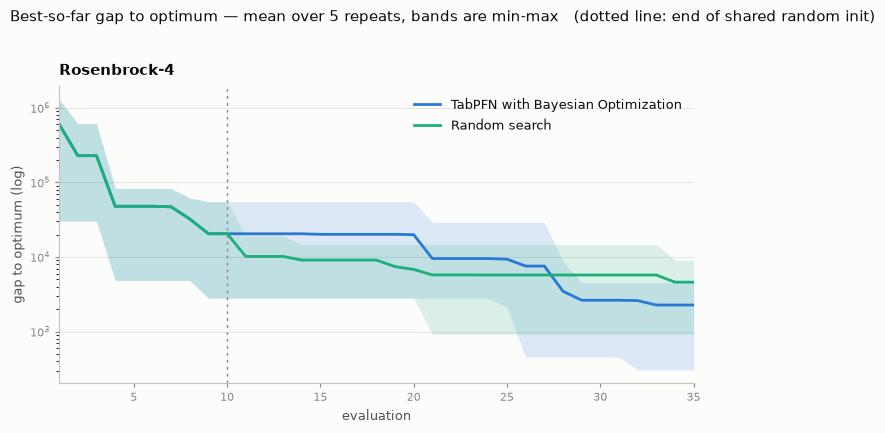

In [6]:
evals = np.arange(1, bo_gap.shape[1] + 1)

fig, ax = plt.subplots(figsize=(7.2, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.set_yscale("log")

# Mean over repeats, band spans min-max across them.
for curves, label, color in [
    (bo_gap, "TabPFN with Bayesian Optimization", "#2a78d6"),
    (random_gap, "Random search", "#1baf7a"),
]:
    ax.fill_between(evals, curves.min(0), curves.max(0), color=color, alpha=0.15, lw=0)
    ax.plot(evals, curves.mean(0), color=color, lw=2, label=label)
ax.axvline(N_INIT, color="#898781", lw=1, ls=(0, (2, 3)))

ax.set_title("Rosenbrock-4", fontsize=11, color="#0b0b0b", loc="left", fontweight="bold", pad=8)
ax.grid(visible=True, axis="y", color="#e1e0d9", linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelsize=8, length=3)
ax.set_xlim(1, N_INIT + N_BO_STEPS)
ax.set_xlabel("evaluation", fontsize=9, color="#52514e")
ax.set_ylabel("gap to optimum (log)", fontsize=9, color="#52514e")
ax.legend(frameon=False, fontsize=9.5, labelcolor="#0b0b0b")

fig.suptitle(
    f"Best-so-far gap to optimum — mean over {N_SEEDS} repeats, bands are min-max"
    "   (dotted line: end of shared random init)",
    fontsize=11,
    color="#0b0b0b",
    x=0.02,
    ha="left",
    y=1.02,
)
fig.tight_layout()
plt.show()


## Takeaways

- `tabpfn-extensions` already provides the Bayesian Optimization loop primitive: `propose_next_point()`
- On Rosenbrock-4 with this small budget, TabPFN-driven Bayesian Optimization ends with a lower mean and median gap to the optimum than random search, but the separation only appears late in the run and single repeats can go either way. Use a larger evaluation budget and more repeats for a clean comparison.
- For more background, start with the upstream [example](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/bayesian_optimization/bayesian_optimization.py) and the [`tabpfn-extensions` repo](https://github.com/PriorLabs/tabpfn-extensions).
